# Visualization

Every figure referenced in the README is generated here, from the artifacts the
earlier notebooks produced: training curves, a parity plot, pressure-field renders,
and the shape-optimization before/after, trajectory plot, and animations.


Load the trained model and everything produced by the earlier notebooks.


In [1]:
import sys, json, os
sys.path.insert(0, "..")

import numpy as np
import torch
from torch_geometric.loader import DataLoader

from src.model import MeshSurrogate
from src.data import load_mesh
from src import viz

os.makedirs("../outputs/figures", exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"

with open("../outputs/norm_stats.json") as f:
    stats = json.load(f)
with open("../outputs/history.json") as f:
    history = json.load(f)

model = MeshSurrogate(in_channels=6).to(device)
model.load_state_dict(torch.load("../outputs/checkpoints/best_model.pt", weights_only=True, map_location=device))
model.eval()

test_data = torch.load("../outputs/cache/test_pyg.pt", weights_only=False)


## Training curves

Pressure and Cd loss, train vs. validation, over all 200 epochs — the plot that
shows the overfitting gap on Cd discussed in the README.


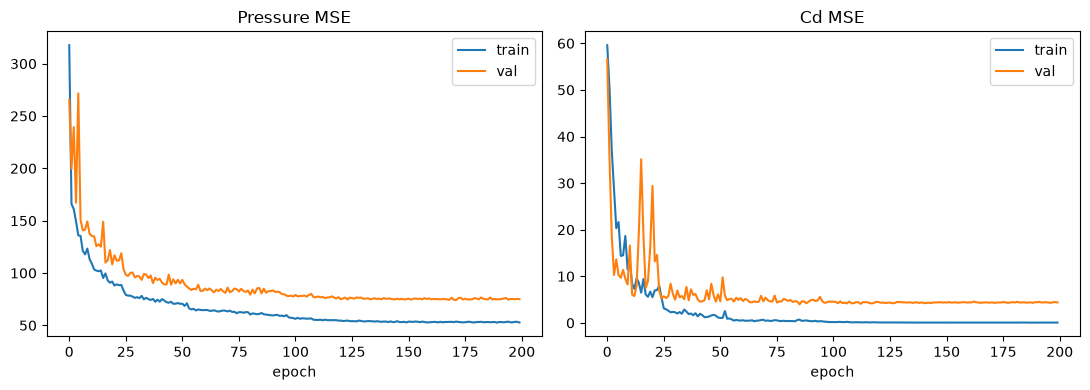

In [2]:
viz.plot_training_curves(history, save_path="../outputs/figures/training_curves.png")


## Parity plot

Predicted vs. true Cd across the entire test set — the standard way to check a
surrogate model's calibration at a glance. Points near the diagonal are good
predictions; systematic drift away from it would mean the model is biased in some
region of the Cd range.


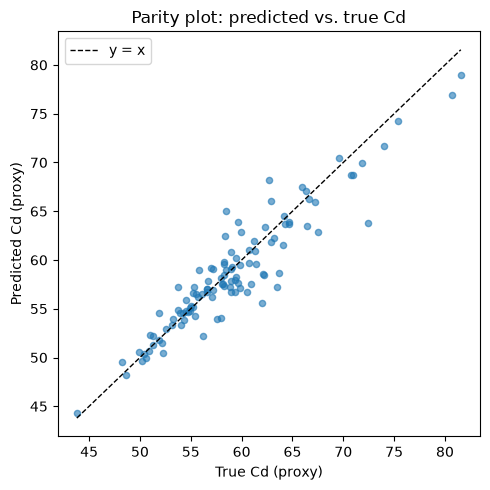

In [3]:
from src.shape_opt import CD_PHYSICAL_SIGN

pressure_mean, pressure_std = stats["pressure_mean"], stats["pressure_std"]
cd_mean, cd_std = stats["cd_mean"], stats["cd_std"]

test_loader = DataLoader(test_data, batch_size=8)
cd_true_all, cd_pred_all = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, cd_pred = model(batch.x, batch.edge_index, batch.batch)
        cd_true_all.append((CD_PHYSICAL_SIGN * (batch.y_cd.squeeze(-1) * cd_std + cd_mean)).cpu().numpy())
        cd_pred_all.append((CD_PHYSICAL_SIGN * (cd_pred * cd_std + cd_mean)).cpu().numpy())
cd_true_all = np.concatenate(cd_true_all)
cd_pred_all = np.concatenate(cd_pred_all)

viz.plot_parity(cd_true_all, cd_pred_all, save_path="../outputs/figures/parity_cd.png")


## Pressure field: ground truth vs. predicted

The centerpiece figure: one held-out test car, colored by pressure — real simulation
output on the left, the model's prediction on the right, on the same color scale.


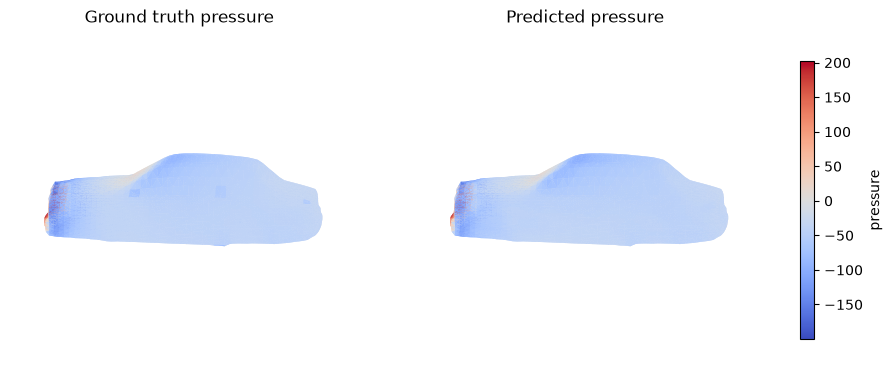

In [4]:
sample = test_data[0]
sample_id = sample.sample_id
verts_norm = sample.x[:, :3].numpy()
_, faces = load_mesh(sample_id)

with torch.no_grad():
    x = sample.x.to(device)
    edge_index = sample.edge_index.to(device)
    batch_vec = torch.zeros(x.shape[0], dtype=torch.long, device=device)
    pressure_pred, _ = model(x, edge_index, batch_vec)

pressure_true = (sample.y_pressure.numpy() * pressure_std) + pressure_mean
pressure_pred_orig = (pressure_pred.cpu().numpy() * pressure_std) + pressure_mean

viz.render_pressure_comparison(verts_norm, faces, pressure_true, pressure_pred_orig, save_path="../outputs/figures/pressure_field_comparison.png")


A single camera angle can flatter a result. This renders the same two pressure
fields from four angles (front, side, rear, top) as a quick check that nothing
looks wrong from a viewpoint the main figure doesn't show.


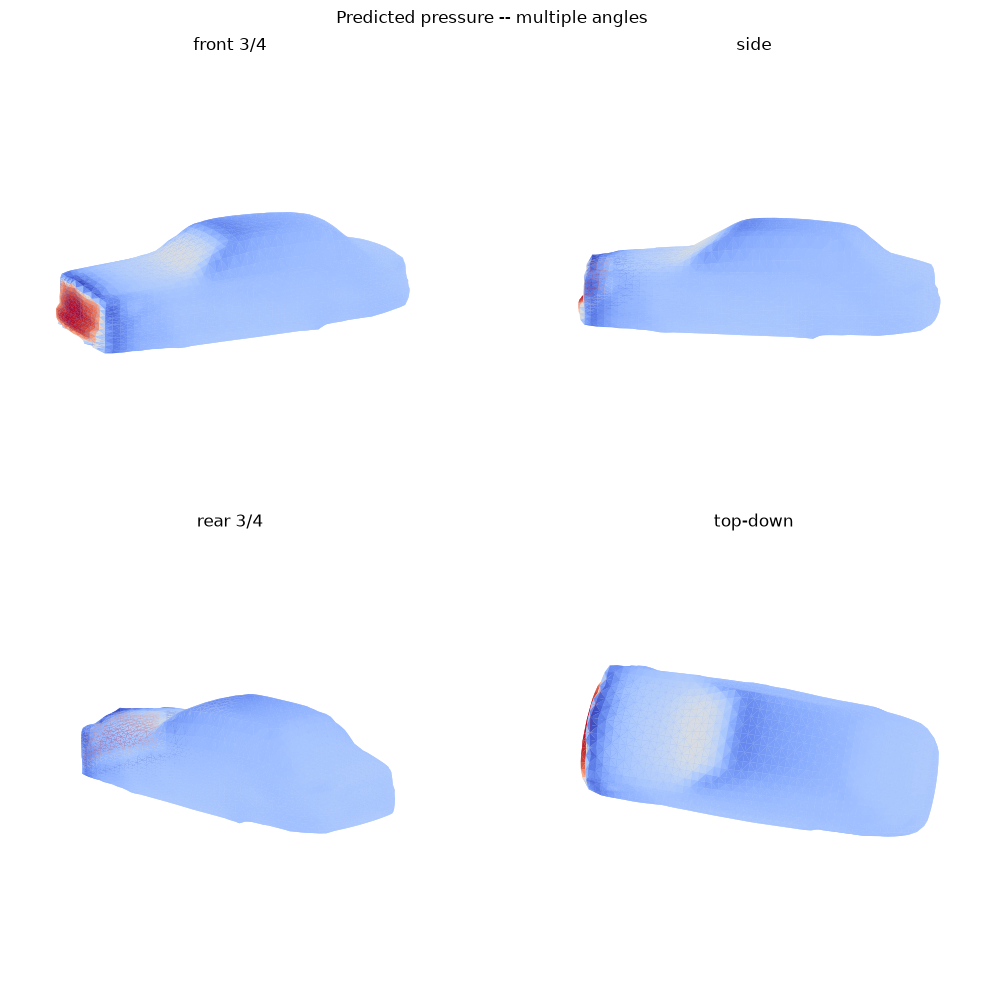

In [5]:
viz.render_pressure_multi_angle(verts_norm, faces, pressure_true, "Ground truth pressure -- multiple angles", save_path="../outputs/figures/pressure_true_multi_angle.png")
viz.render_pressure_multi_angle(verts_norm, faces, pressure_pred_orig, "Predicted pressure -- multiple angles", save_path="../outputs/figures/pressure_pred_multi_angle.png")


A rotatable, zoomable version of the same comparison, saved as a standalone HTML
file — open it in a browser to inspect the pressure field from any angle rather
than trust a single fixed camera choice.


In [6]:
viz.interactive_pressure_comparison(verts_norm, faces, pressure_true, pressure_pred_orig, save_path="../outputs/figures/pressure_field_interactive.html")
print("saved interactive pressure comparison to ../outputs/figures/pressure_field_interactive.html")


saved interactive pressure comparison to ../outputs/figures/pressure_field_interactive.html


## Shape optimization

Load the trajectory saved by `shape_optimization.ipynb` and plot how the predicted
Cd changed step by step during the optimization.

Max vertex displacement is about 1.7% of the car's length -- small, but roughly
seven times what the earlier free-vertex version managed before its own early stop.
The renders below still exaggerate it by a labeled factor so the *character* of the
deformation is visible; the printed numbers are always the real, unexaggerated
values. Note that 5x here is a larger absolute deformation than the 20x used by the
free-vertex version, and the shape stays recognizably a car -- which is the point of
optimizing FFD control points instead of raw vertices.

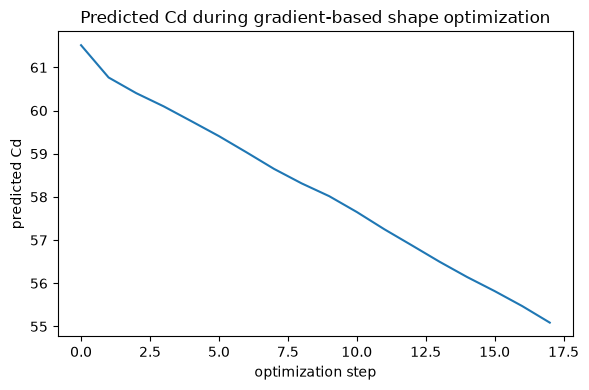

In [7]:
opt_result = torch.load("../outputs/shape_opt_result.pt", weights_only=False)
faces_opt = opt_result["faces"]
pos_history = opt_result["pos_history"]
pressure_history = opt_result["pressure_history"]
cd_over_steps = opt_result["cd_over_steps"]
verification = opt_result["verification"]

DISPLACEMENT_EXAGGERATION = 5  # visualization only -- see markdown above

viz.plot_cd_over_steps(cd_over_steps, save_path="../outputs/figures/cd_over_optimization_steps.png")

The original shape next to the optimized one, both colored by predicted pressure on
a shared scale, with the verification numbers underneath.

Read the caption in this order: **drag force** is the physically meaningful result;
**frontal area and volume** must both be near zero or the "improvement" is just the
car being resized rather than reshaped; and the **Cd head** figure is the quantity
being optimized against, so it is the least independent of the three.

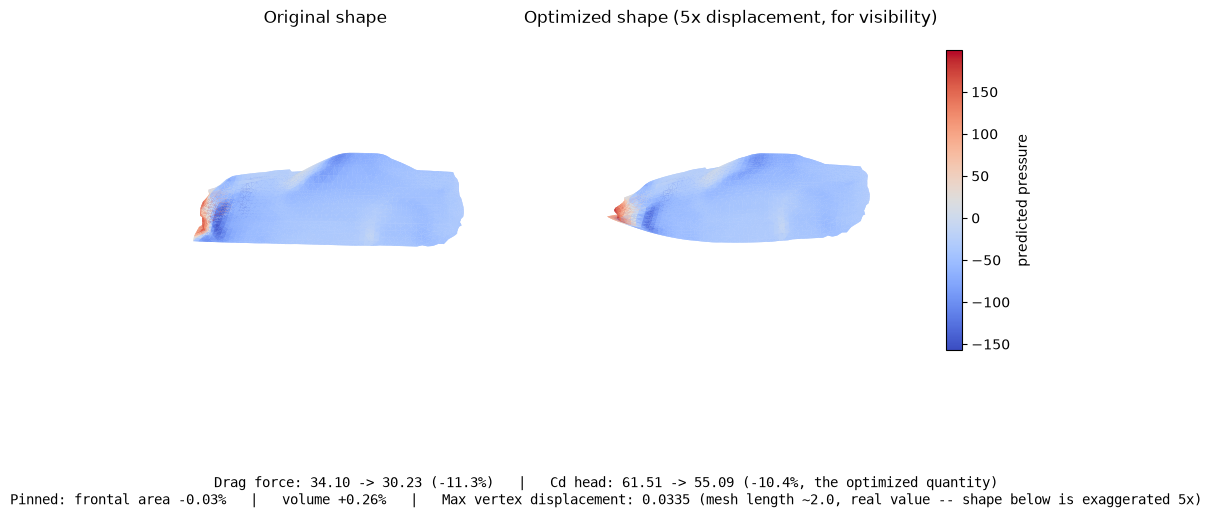

In [8]:
stats_text = (
    f"Drag force: {verification['before']['analytic_drag_force']:.2f} -> {verification['after']['analytic_drag_force']:.2f} "
    f"({verification['drag_force_pct_change']:+.1f}%)   |   "
    f"Cd head: {verification['before']['cd_head_raw']:.2f} -> {verification['after']['cd_head_raw']:.2f} "
    f"({verification['cd_head_pct_change']:+.1f}%, the optimized quantity)\n"
    f"Pinned: frontal area {verification['frontal_area_pct_change']:+.2f}%   |   "
    f"volume {verification['volume_pct_change']:+.2f}%   |   "
    f"Max vertex displacement: {verification['displacement']['max']:.4f} "
    f"(mesh length ~2.0, real value -- shape below is exaggerated {DISPLACEMENT_EXAGGERATION}x)"
)
viz.render_shape_before_after(
    pos_history[0], pos_history[-1], faces_opt,
    pressure_before=pressure_history[0], pressure_after=pressure_history[-1],
    stats_text=stats_text,
    exaggeration=DISPLACEMENT_EXAGGERATION,
    save_path="../outputs/figures/shape_before_after.png",
)

An animated version morphing through every recorded step, also colored by
predicted pressure so the (small) change is easier to see than in a static
before/after.


In [9]:
viz.make_morph_gif(pos_history, faces_opt, save_path="../outputs/figures/shape_morph.gif", pressure_history=pressure_history, cd_over_steps=cd_over_steps, stride=5, fps=10, exaggeration=DISPLACEMENT_EXAGGERATION)
print("saved GIF to ../outputs/figures/shape_morph.gif")


saved GIF to ../outputs/figures/shape_morph.gif


And finally an interactive version of the same trajectory — rotatable, zoomable, and
scrubbable with a step slider, saved as a standalone HTML file.


In [10]:
viz.interactive_shape_optimization(pos_history, faces_opt, cd_over_steps, save_path="../outputs/figures/shape_optimization_interactive.html", pressure_history=pressure_history, stride=2, exaggeration=DISPLACEMENT_EXAGGERATION)
print("saved interactive shape optimization to ../outputs/figures/shape_optimization_interactive.html")


saved interactive shape optimization to ../outputs/figures/shape_optimization_interactive.html
